## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.

## Завдання 1
 - Дослідіть вплив функцій активації на результати моделі.
 - Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
 - Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
 - Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
 - Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
 - Оформіть результати в таблиці:

| Активація | MAE | R² |
| :--- | :---: | :---: |
| ReLU | ... | ... |
| Tanh | ... | ... |
| LeakyReLU | ... | ... |
| Swish | ... | ... |

In [1]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1) * 0.1
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1) * 0.1

In [2]:
import torch.nn as nn

activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "SiLU": nn.SiLU(),
    "Swish": nn.SiLU(),
}

In [3]:
class Mlp(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x, mode='test') :
        return self.layers(x)

In [4]:
def train_model(model, X, y, epochs=1000, lr=0.01) :
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs) : 
        output = model(X, 'train')
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses

In [5]:
mlps = { k: Mlp(activation=k) for k in activators.keys() }
#mlps

In [6]:
def train_models_set(mlps, xtrain, ytrain) :
    losses = {}
    predictions = {}
    for k, mlp in mlps.items():
        losses[k] = train_model(mlp, xtrain, ytrain)
        with torch.no_grad():
            predictions[k] = mlp(xtest)
    return losses, predictions

In [7]:
losses, predictions = train_models_set(mlps, xtrain, ytrain)
        
print(*zip(*(predictions[k][:5] for k in mlps.keys()), ytest[:5]), sep='\n')

(tensor([30.0237]), tensor([30.6220]), tensor([31.0461]), tensor([30.6716]), tensor([31.0537]), tensor([30.7592]), tensor([29.6891]))
(tensor([-23.0829]), tensor([-21.8273]), tensor([-22.0634]), tensor([-21.9291]), tensor([-21.8362]), tensor([-21.9029]), tensor([-22.9669]))
(tensor([-19.7009]), tensor([-18.4638]), tensor([-18.3631]), tensor([-18.5607]), tensor([-18.3196]), tensor([-18.4531]), tensor([-19.6114]))
(tensor([8.4904]), tensor([7.6798]), tensor([7.3983]), tensor([7.3193]), tensor([7.5352]), tensor([7.5947]), tensor([8.4673]))
(tensor([-42.9006]), tensor([-48.8752]), tensor([-48.1507]), tensor([-49.0780]), tensor([-49.1574]), tensor([-49.2592]), tensor([-48.8315]))


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Перетворюємо ytest у формат numpy масиву та згладжуємо
y_true = ytest.detach().cpu().numpy().flatten()

results = []

# Перебираємо активації, які є у вашому словнику mlps
for k in mlps.keys():
    # Отримуємо прогноз моделі, перетворюємо в numpy та згладжуємо
    y_pred = predictions[k].detach().cpu().numpy().flatten()
    
    # Рахуємо метрики
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Додаємо в список результатів
    results.append({
        "Активація": k,
        "MAE": round(mae, 4),
        "R²": round(r2, 4)
    })

# Створюємо датафрейм та виводимо у форматі Markdown
df_results = pd.DataFrame(results)
#print(df_results.to_markdown(index=False))
df_results

,Активація,MAE,R²
0,Sigmoid,1.3409,0.9900
1,ReLU,0.8509,0.9972
2,Tanh,0.8919,0.9967
3,LeakyReLU,0.8403,0.9973
4,SiLU,0.8436,0.9973
5,Swish,0.8457,0.9973


In [9]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

def score_table(ytest, predictions):
    return md("\n".join((
        "|Активація|MAE|R²|",
        "|-|-|-|",
        *(f"|{k}|{sm.mean_absolute_error(ytest, v):.4f}|{sm.r2_score(ytest, v):.4f}|" for k, v in predictions.items())
    )))

score_table(ytest, predictions)

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.3409|0.9900|
|ReLU|0.8509|0.9972|
|Tanh|0.8919|0.9967|
|LeakyReLU|0.8403|0.9973|
|SiLU|0.8436|0.9973|
|Swish|0.8457|0.9973|

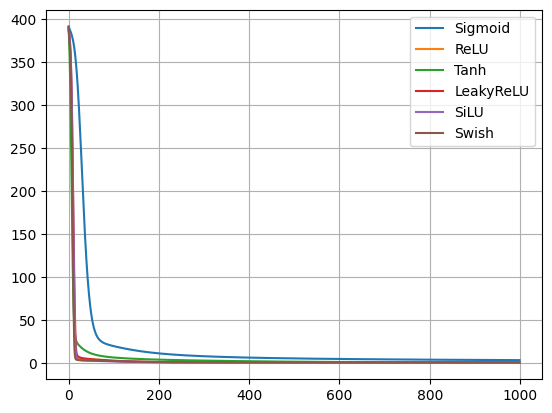

In [10]:
import matplotlib.pyplot as plt

def plot_losses(losses): 
    _, ax = plt.subplots()
    for k, v in losses.items():
        ax.plot(v, label=k)
    ax.legend()
    ax.grid()
    plt.show()
plot_losses(losses)

## Завдання 2
Додайте Dropout і проаналізуйте вплив регуляризації.
 - Використовуйте ту саму архітектуру MLP.
 - Додайте шар torch.nn.Dropout(p=0.3) після прихованого шару.
 - Порівняйте результати до і після застосування Dropout за MAE і R².
 - Зробіть висновок: чи допомагає Dropout уникнути перенавчання?

In [11]:
class Mlp(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(hidden_size, output_size)
    def forward(self, x, mode='test') :
        x = self.hidden(x)
        x = self.activation(x)
        if mode != 'test' :
            x = self.dropout(x)
        x = self.output(x)
        return x

In [12]:
mlps_d = { k: Mlp(activation=k) for k in activators.keys() }
losses_d, predictions_d = train_models_set(mlps_d, xtrain, ytrain)
        
print(*zip(*(predictions_d[k][:5] for k in mlps_d.keys()), ytest[:5]), sep='\n')
score_table(ytest, predictions_d)

(tensor([31.0613]), tensor([29.8999]), tensor([31.9562]), tensor([29.8286]), tensor([29.8085]), tensor([30.1543]), tensor([29.6891]))
(tensor([-21.3466]), tensor([-21.2986]), tensor([-22.8579]), tensor([-21.3138]), tensor([-21.4887]), tensor([-21.3156]), tensor([-22.9669]))
(tensor([-17.7443]), tensor([-18.0247]), tensor([-19.8385]), tensor([-18.0874]), tensor([-18.3153]), tensor([-17.9667]), tensor([-19.6114]))
(tensor([6.7306]), tensor([7.2258]), tensor([6.9129]), tensor([7.0562]), tensor([7.3938]), tensor([7.3289]), tensor([8.4673]))
(tensor([-44.6900]), tensor([-47.8205]), tensor([-43.8113]), tensor([-47.7739]), tensor([-48.0249]), tensor([-47.7417]), tensor([-48.8315]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.1255|0.9933|
|ReLU|0.8960|0.9969|
|Tanh|1.7753|0.9856|
|LeakyReLU|0.8852|0.9970|
|SiLU|0.8620|0.9971|
|Swish|0.8869|0.9969|

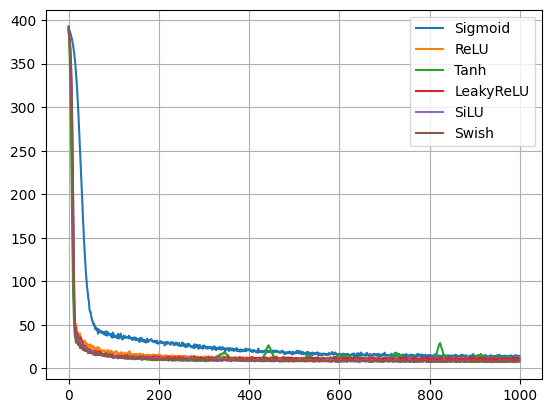

In [13]:
plot_losses(losses_d)

Графік в другому випадку став більше рваним ніж в першому, через Dropout

## Завдання 3
Додайте Batch Normalization для стабілізації навчання.
 - Використовуйте шар torch.nn.BatchNorm1d після лінійного шару.
 - Навчіть модель і побудуйте графік функції втрат за епохами.
 - Порівняйте розкид loss з попередніми експериментами.

In [14]:
class MlpBatch(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(MlpBatch, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x, mode='test') :
        x = self.layers(x)
        return x

In [15]:
mlps_b = { k: MlpBatch(activation=k) for k in activators.keys() }
losses_b, predictions_b = train_models_set(mlps_b, xtrain, ytrain)
        
print(*zip(*(predictions_b[k][:5] for k in mlps_b.keys()), ytest[:5]), sep='\n')
score_table(ytest, predictions_b)

(tensor([30.9861]), tensor([31.1076]), tensor([31.6659]), tensor([31.4237]), tensor([30.9649]), tensor([31.4098]), tensor([29.6891]))
(tensor([-22.1910]), tensor([-20.5034]), tensor([-21.4201]), tensor([-20.4762]), tensor([-20.2822]), tensor([-20.4596]), tensor([-22.9669]))
(tensor([-17.4997]), tensor([-17.3826]), tensor([-17.0817]), tensor([-17.2466]), tensor([-17.2053]), tensor([-17.4986]), tensor([-19.6114]))
(tensor([9.3589]), tensor([8.4835]), tensor([8.5099]), tensor([8.0439]), tensor([8.4036]), tensor([8.4029]), tensor([8.4673]))
(tensor([-42.0701]), tensor([-47.2731]), tensor([-44.5552]), tensor([-47.3423]), tensor([-47.0183]), tensor([-47.2504]), tensor([-48.8315]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.5849|0.9871|
|ReLU|1.1266|0.9953|
|Tanh|1.2720|0.9926|
|LeakyReLU|1.1395|0.9950|
|SiLU|1.1556|0.9949|
|Swish|1.1535|0.9950|

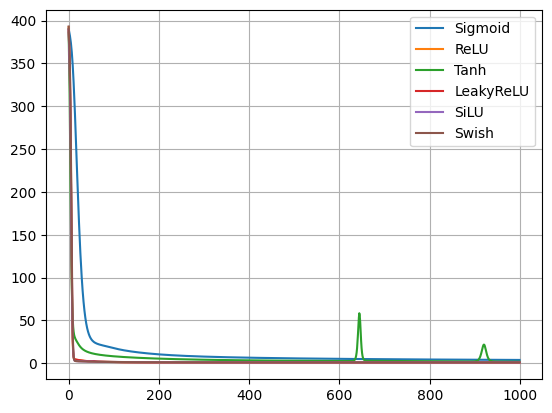

In [16]:
plot_losses(losses_b)

# ReLU + Dropout + BatchNorm

In [23]:
class MlpDropoutBatch(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(MlpDropoutBatch, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.batch = nn.BatchNorm1d(hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, x, mode='test') :
        x = self.hidden(x)
        x = self.batch(x)
        x = self.activation(x)
        if mode != 'test' :
            x = self.dropout(x)
        x = self.output(x)
        return x

In [24]:
mlps_db = { k: MlpDropoutBatch(activation=k) for k in activators.keys() }
losses_db, predictions_db = train_models_set(mlps_db, xtrain, ytrain)
        
print(*zip(*(predictions_db[k][:5] for k in mlps_db.keys()), ytest[:5]), sep='\n')
score_table(ytest, predictions_db)

(tensor([31.4238]), tensor([30.1392]), tensor([31.1143]), tensor([30.2212]), tensor([30.1084]), tensor([30.1927]), tensor([29.6891]))
(tensor([-19.5200]), tensor([-19.6434]), tensor([-20.0010]), tensor([-19.5793]), tensor([-19.7642]), tensor([-19.8764]), tensor([-22.9669]))
(tensor([-15.9895]), tensor([-16.5029]), tensor([-16.8792]), tensor([-16.3688]), tensor([-16.4018]), tensor([-16.9152]), tensor([-19.6114]))
(tensor([7.7048]), tensor([7.9089]), tensor([9.9495]), tensor([8.1187]), tensor([8.2108]), tensor([8.2037]), tensor([8.4673]))
(tensor([-43.3256]), tensor([-45.4202]), tensor([-40.7006]), tensor([-44.9076]), tensor([-46.3771]), tensor([-46.5667]), tensor([-48.8315]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.5154|0.9892|
|ReLU|1.3104|0.9932|
|Tanh|2.3710|0.9796|
|LeakyReLU|1.4286|0.9917|
|SiLU|1.2584|0.9938|
|Swish|1.2364|0.9940|

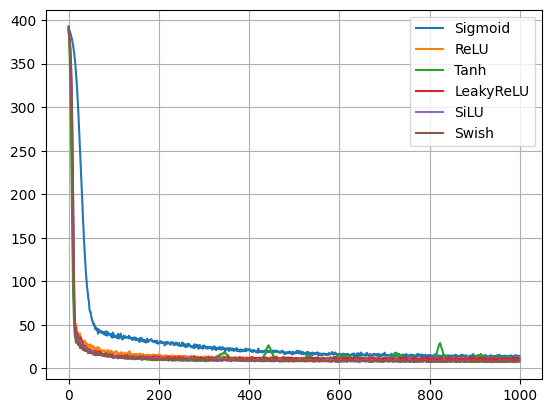

In [25]:
plot_losses(losses_d)

## Завдання 4
Зробіть підсумкове порівняння всіх варіантів моделі.
 - Об'єднайте результати у зведену таблицю:
|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|...|...|
|ReLU + Dropout|...|...|
|ReLU + BatchNorm|...|...|
|ReLU + Dropout + BatchNorm|...|...|

 - Визначте, яка комбінація дає найбільш стійке навчання.
 - Сформулюйте короткий висновок (3-4 речення) у стилі технічного звіту.

In [29]:
md(f""" 
|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|{sm.mean_absolute_error(ytest, predictions["ReLU"])}|{sm.r2_score(ytest, predictions["ReLU"]}|
|ReLU + Dropout|{sm.mean_absolute_error(ytest, predictions_d["ReLU"])}|...|
|ReLU + BatchNorm|{sm.mean_absolute_error(ytest, predictions_b["ReLU"])}|...|
|ReLU + Dropout + BatchNorm|{sm.mean_absolute_error(ytest, predictions_db["ReLU"])}|...|
""")

SyntaxError: closing parenthesis '}' does not match opening parenthesis '(' (1779343758.py, line 4)